In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib.path as mpath
from matplotlib.patches import Ellipse
from scipy.odr import ODR, Model, Data
from scipy import constants
from scipy.stats import spearmanr

from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import Gaussian2DKernel, convolve


SAVE_FIGS = True

L_BOUNDS = [16.26, 32.26] # degrees
B_BOUNDS = [-1.46, 1.44] # degrees
REGSIZEL = 2.0

# LINUX_DIRECTORY = '/home/aimee/mphys' # Aimee
LINUX_DIRECTORY = '/home/u20482jg/MPHYS_Project_Local' # Joe
# MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/maps' # Aimee
MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/all_maps/maps' # Joe
FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures/maps_and_TTplots' # Joe
CSV_SAVEDIR = f'{LINUX_DIRECTORY}/results_files/longitude_intercept_fits'

# FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures' # Aimee
FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures/difference_maps' # Joe

TTRESPREFIX = f"{LINUX_DIRECTORY}/results_files/longitude_intercept_fits/TT_Plots_for_{REGSIZEL}x3.0_degree_rectangles_-_"
THEORVALSPREFIX = f"{LINUX_DIRECTORY}/results_files/GDIGS_Theoretical_values/Theoretical_gradients"


COMAP_MAPS = { # name : [file name, frequency / Hz]
    "COMAP 26.5 GHz" : ["comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 26.5e9],
    "COMAP 27.5 GHz" : ["comap_alr-2_galactic_301025_band01_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 27.5e9],
    "COMAP 28.5 GHz" : ["comap_alr-2_galactic_301025_band02_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 28.5e9],
    "COMAP 29.5 GHz" : ["comap_alr-2_galactic_301025_band03_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 29.5e9],
    "COMAP 30.5 GHz" : ["comap_alr-2_galactic_301025_band04_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 30.5e9],
    "COMAP 31.5 GHz" : ["comap_alr-2_galactic_301025_band05_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 31.5e9],
    "COMAP 32.5 GHz" : ["comap_alr-2_galactic_301025_band06_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 32.5e9],
    "COMAP 33.5 GHz" : ["comap_alr-2_galactic_301025_band07_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 33.5e9]
}


# User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index
EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    # "Effelsberg 1.43 GHz (10')" : ["EFFELSBERG-1.4285714285714286GHz-10.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (15')" : ["EFFELSBERG-1.4285714285714286GHz-15.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (20')" : ["EFFELSBERG-1.4285714285714286GHz-20.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (25')" : ["EFFELSBERG-1.4285714285714286GHz-25.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (30')" : ["EFFELSBERG-1.4285714285714286GHz-30.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (60')" : ["EFFELSBERG-1.4285714285714286GHz-60.0amin.fits", 1.4285714285714286e9],
    "Effelsberg 2.73 GHz (5 amin)" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (10')" : ["EFFELSBERG-2.7272727272727275GHz-10.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (15')" : ["EFFELSBERG-2.7272727272727275GHz-15.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (20')" : ["EFFELSBERG-2.7272727272727275GHz-20.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (25')" : ["EFFELSBERG-2.7272727272727275GHz-25.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (30')" : ["EFFELSBERG-2.7272727272727275GHz-30.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (60')" : ["EFFELSBERG-2.7272727272727275GHz-60.0amin.fits", 2.7272727272727275e9]
}

GDIGS_MAPS = { # name : [file name, frequency / Hz]
    # Note to self: create a GDIGS mosaic smoothed to 5 arcmin?
    "GDIGS Moment 0" : ["gdigs_moment0_mosaic_1arcmin.fits", 5.76e9] # CHECK GDIGS FREQUENCY
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
    "Nobeyama 10.0GHz (5 amin)" : ["NOBEYAMA-10.0GHz-5.0amin.fits", 10.3e9]
    # "Nobeyama 10.0GHz (10 amin)"  : ["NOBEYAMA-10.0GHz-10.0amin.fits", 9.4e9]
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    "PARKES 5GHz (5')" : ["Parkes_5.0GHz_raw.fits", 5e9],
    # "PARKES 5GHz (10')" : ["PARKES-5.0GHz-10.0amin.fits", 5e9]
}


SINO_GERMAN_MAPS = { # name : [file name, frequency / Hz]
    "Sino German 5.0GHz (10 amin)" : ["SinoGermanSurvey-5.0GHz-10.0amin.fits", 5e9]
}

AKARI_MAPS = { # name : [file name, frequency / Hz]
    # "Akari 1875 GHz (5 amin)" : ["AKARI-1874.9999999999998GHz-5.0amin.fits", 1874.9999999999998e9],
    "Akari 1875 GHz (10')" : ["AKARI-1874.9999999999998GHz-10.0amin.fits", 1874.9999999999998e9],
    # "Akari 2143 GHz (5 amin)" : ["AKARI-2142.857142857143GHz-5.0amin.fits", 2142.857142857143e9],
    "Akari 2143 GHz (10')" : ["AKARI-2142.857142857143GHz-10.0amin.fits", 2142.857142857143e9],
    # "Akari 3333 GHz (5 amin)" : ["AKARI-3333.333333333333GHz-5.0amin.fits", 3333.333333333333e9],
    "Akari 3333 GHz (10')" : ["AKARI-3333.333333333333GHz-10.0amin.fits", 3333.333333333333e9],
    # "Akari 4615 GHz (5 amin)" : ["AKARI-4615.384615384616GHz-5.0amin.fits", 4615.384615384616e9],
    "Akari 4615 GHz (10')" : ["AKARI-4615.384615384616GHz-10.0amin.fits", 4615.384615384616e9]
}


map_keyslist = (
    EFFELSBERG_MAPS |
    NOBEYAMA_MAPS |
    COMAP_MAPS
).keys()


thvals_file = np.genfromtxt(f"{THEORVALSPREFIX}.csv", delimiter=',', dtype=str)
theoretical_values = {}
for i, key in enumerate(thvals_file[0,:]):
    theoretical_values[key] = float(thvals_file[1,i])

# theoretical_values = {
#     "Effelsberg 2.73 GHz (5 amin)": 2.7496319562176463,
#     "Nobeyama 10.0GHz (5 amin)" : 0.16642387303282855,
#     "COMAP 26.5 GHz" : 0.022355532712697176,
#     "COMAP 27.5 GHz" : 0.02065895444310963,
#     "COMAP 28.5 GHz" : 0.019144693943702513,
#     "COMAP 29.5 GHz" : 0.017787773366125848,
#     "COMAP 30.5 GHz" : 0.016567328003706947,
#     "COMAP 31.5 GHz" : 0.015465822191749221,
#     "COMAP 32.5 GHz" : 0.01446843381585771,
#     "COMAP 33.5 GHz" : 0.013562567298030034
# }


number of regions: 8


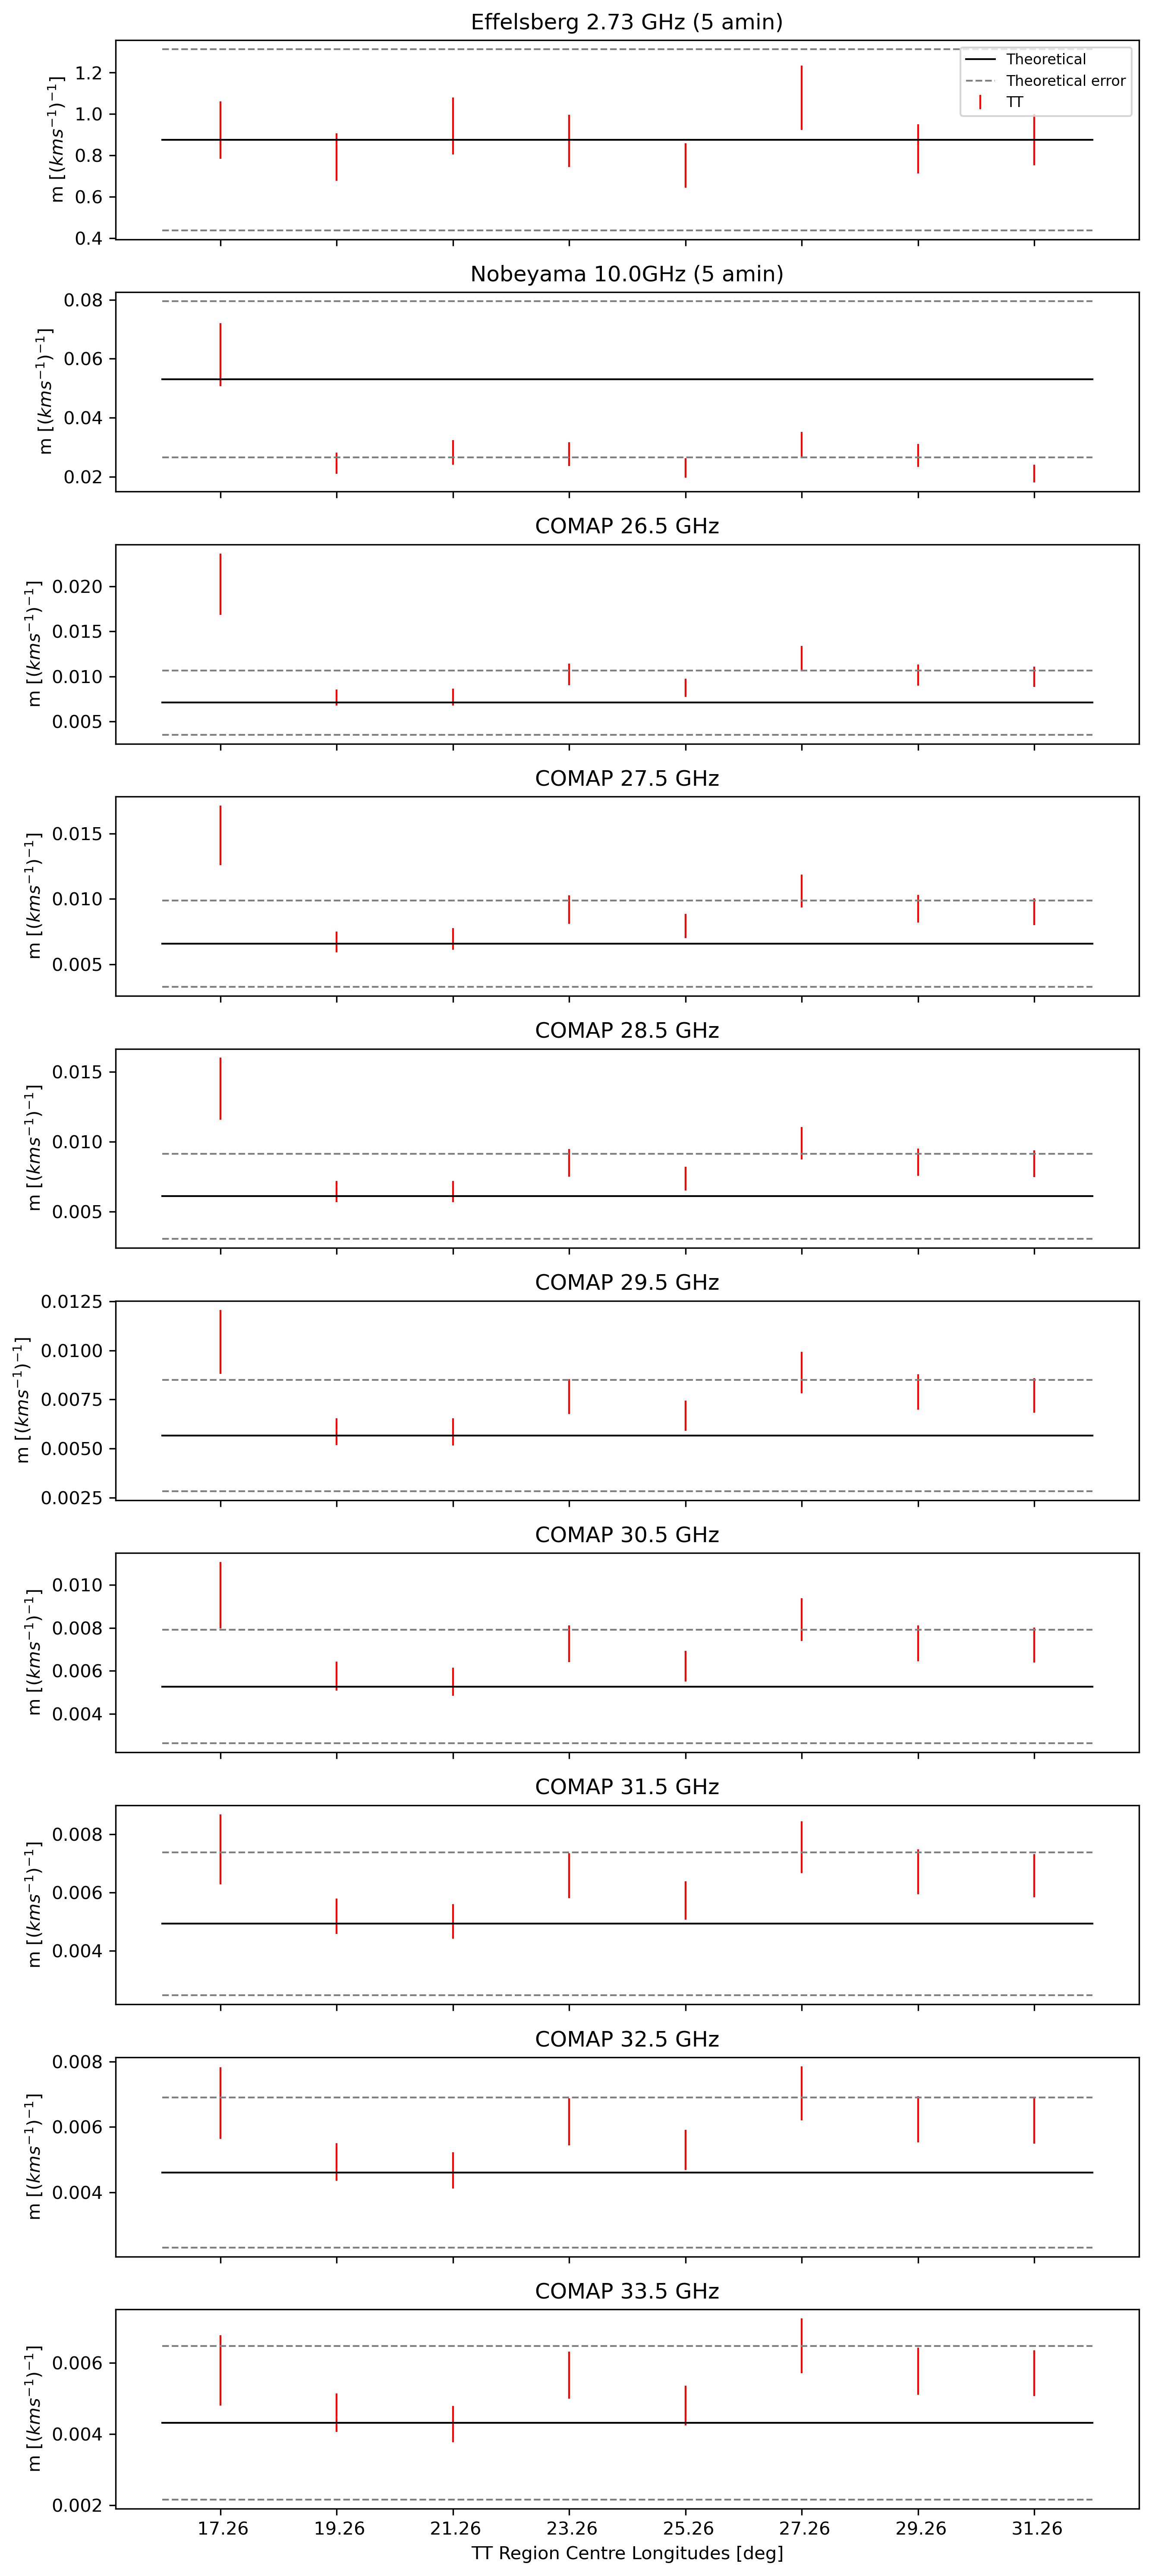

In [2]:
gdigs_name = "GDIGS Moment 0"

fig, axs = plt.subplots(ncols=1, nrows=len(map_keyslist), figsize=(9,2*len(map_keyslist)), dpi=300, sharex=True)
l_min = L_BOUNDS[0]
l_max = L_BOUNDS[1]
n_reg = int((l_max-l_min)/REGSIZEL + 1)
print(f"number of regions: {n_reg}")
longmins = np.linspace(l_min, l_max-REGSIZEL, n_reg)
longcens = longmins + REGSIZEL/2
# print(longcens)

# plt.errorbar
# plt.tick_params


for i, key in enumerate(map_keyslist):
    m_filename      = f"{TTRESPREFIX}{'_'.join(key.split(' '))}_vs_{'_'.join(gdigs_name.split(' '))}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_m_numresults.csv"
    merr_filename   = f"{TTRESPREFIX}{'_'.join(key.split(' '))}_vs_{'_'.join(gdigs_name.split(' '))}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_merr_numresults.csv"

    m_vals = np.genfromtxt(m_filename,       dtype=float, delimiter=',')
    m_errs = np.genfromtxt(merr_filename,    dtype=float, delimiter=',')

    theo_x = np.linspace(l_min, l_max, 1000)
    theo_val = np.zeros_like(theo_x) + theoretical_values[key]
    theo_err = 0.5*theo_val

    ax = axs[i]
    ax.errorbar(longcens, m_vals, m_errs, linewidth=0, elinewidth=1, ecolor='red', barsabove=True, label='TT')
    ax.plot(theo_x, theo_val, linestyle='solid', linewidth=1, color='black', label='Theoretical')
    ax.plot(theo_x, theo_val+theo_err, linestyle='--', linewidth=1, color='grey', label='Theoretical error')
    ax.plot(theo_x, theo_val-theo_err, linestyle='--', linewidth=1, color='grey')
    xtick_labels = [f"{longcen: .2f}" for longcen in longcens]
    ax.set_xticks(longcens, labels=xtick_labels)

    ax.set_ylabel(r"m [$(kms^{-1})^{-1}$]")
    if i == len(axs)-1:
        ax.set_xlabel("TT Region Centre Longitudes [deg]")

    if i == 0:
        ax.legend(fontsize=8)
    
    ax.set_title(f"{key}")

fig.tight_layout()